# Metro Interstate Traffic Volume Prediction

## Machine Learning Capstone Project — Regression Track

### Problem Statement

The objective of this project is to predict traffic volume on the Metro Interstate Highway of Minneapolis-St Paul using available weather, holiday, and time-related features.

### Target Variable

`traffic_volume`

### Problem Type

Regression


## SECTION - A
### A1. Dataset loading & audit

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# import warnings
# warnings.filterwarnings("ignore")

#### Load Dataset


In [2]:
df = pd.read_csv("data/Metro_Interstate_Traffic_Volume.csv")

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


#### Dataset Shape

In [3]:
print("No of Rows :", df.shape[0])
print("No of Columns :", df.shape[1])

No of Rows : 48204
No of Columns : 9


#### Statistical Summary


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [5]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


#### Null values

In [6]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

#### Duplicates

In [7]:
df.duplicated().sum()

np.int64(17)

## A2. EDA visualisations

### Target Variable Distribution

The target variable `traffic_volume` is a continuous numerical variable.
Its distribution is examined to understand its range, spread, and overall pattern.

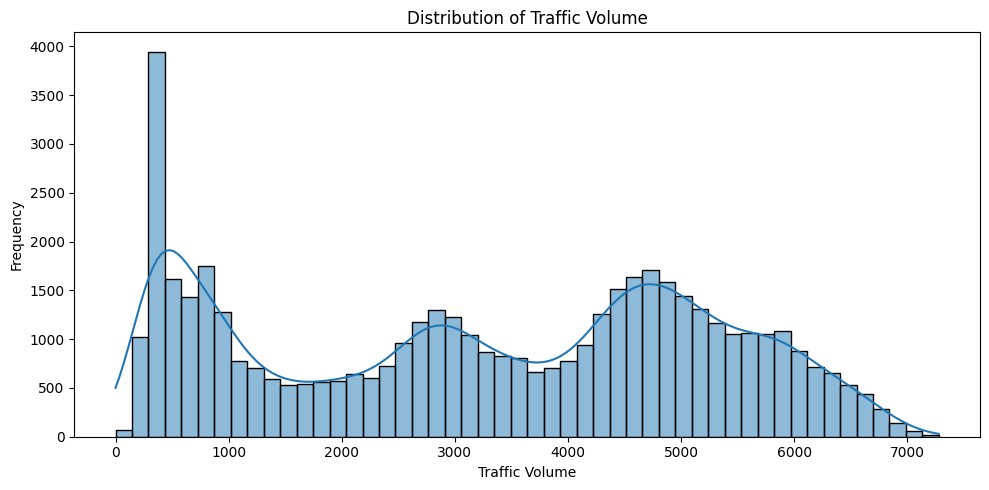

In [8]:
# Histogram
plt.figure(figsize=(10,5))

sns.histplot(data=df, x="traffic_volume", bins=50, kde=True)

plt.title("Distribution of Traffic Volume")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

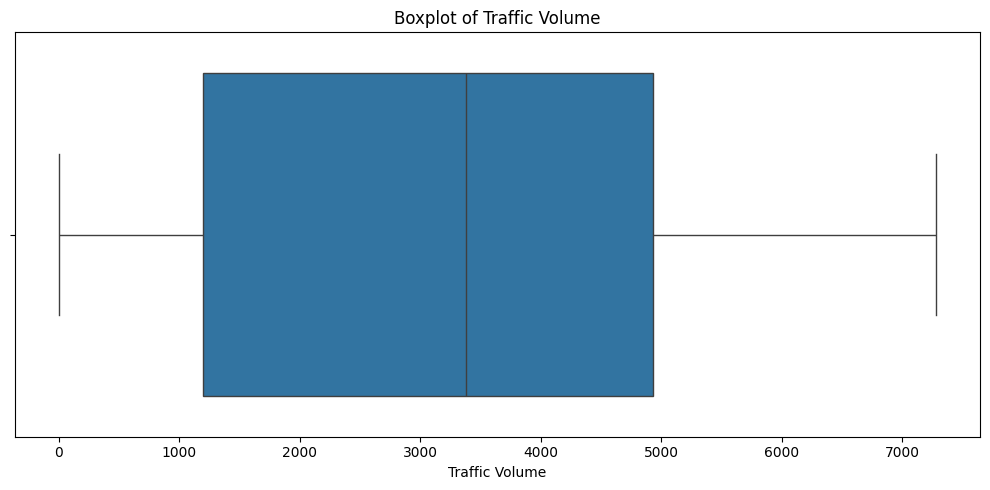

In [9]:
# Boxplot
plt.figure(figsize=(10,5))

sns.boxplot(x=df["traffic_volume"])

plt.title("Boxplot of Traffic Volume")
plt.xlabel("Traffic Volume")
plt.tight_layout()
plt.show()

### Observations
The traffic volume distribution is multimodal, with several distinct peaks. Most observations fall within the middle range, while relatively few observations occur at the extreme low end. This indicates that `traffic_volume` varies acorss different traffic conditions rather than following a single simple distribution.

### Numerical Feature Distributions

The distributions of the numerical features are examined here to understand their ranges, spread, skewness, and potential unusual values.

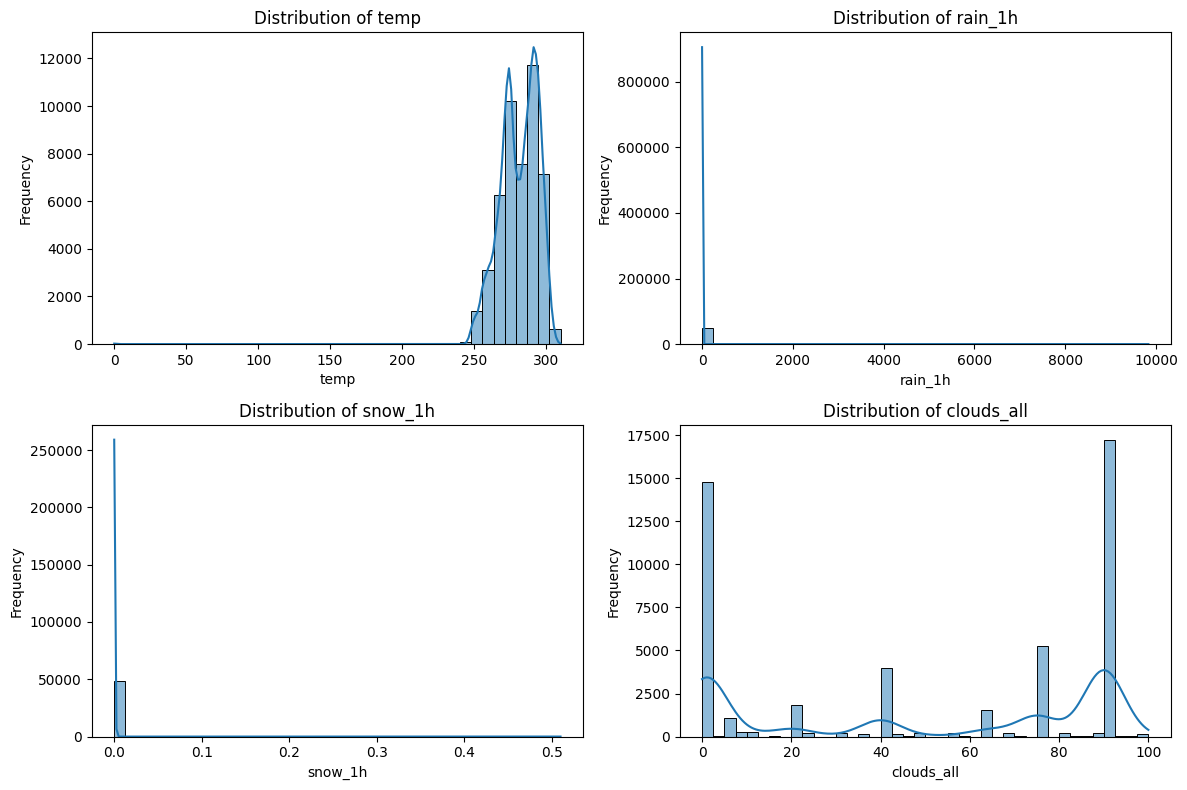

In [10]:
numerical_features = ["temp", "rain_1h", "snow_1h", "clouds_all"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flat, numerical_features):
    sns.histplot(data=df, x=feature, bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation
The `temp` values are concentrated within a relatively narrow range. Both `rain_1h` and `snow_1h` are highly concentrated at zero, indicating that most observations have no recorded rainfall or snowfall. `clouds_all` shows values concentrated at specific discrete levels rather than a smooth continuous distribution.

### Scatter Plot

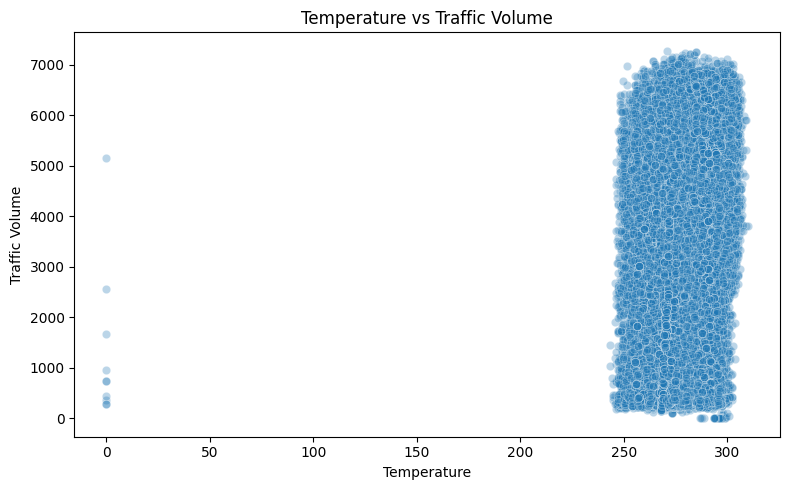

In [11]:
# temp → traffic_volume
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="temp", y="traffic_volume", alpha=0.3)

plt.title("Temperature vs Traffic Volume")
plt.xlabel("Temperature")
plt.ylabel("Traffic Volume")
plt.tight_layout()
plt.show()

### Observation
Most temperature observations are concentrated between approximately 250 and 310, while a small number occur near zero. Traffic volume varies considerably across the main temperature range, indicating no clear linear relationship between `temp` and `traffic_volume`.

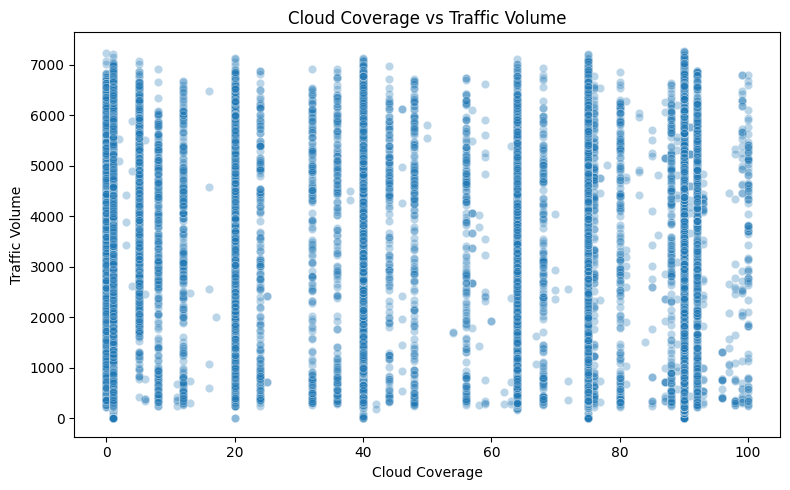

In [12]:
# clouds_all → traffic_volume
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="clouds_all", y="traffic_volume", alpha=0.3)

plt.title("Cloud Coverage vs Traffic Volume")
plt.xlabel("Cloud Coverage")
plt.ylabel("Traffic Volume")
plt.tight_layout()
plt.show()

### Observation
Cloud coverage occurs at distinct levels, producing vertical bands in the scatter plot. Traffic volume varies widely across most cloud-coverage levels, so no clear linear relationship is visible between `clouds_all` and `traffic_volume`.

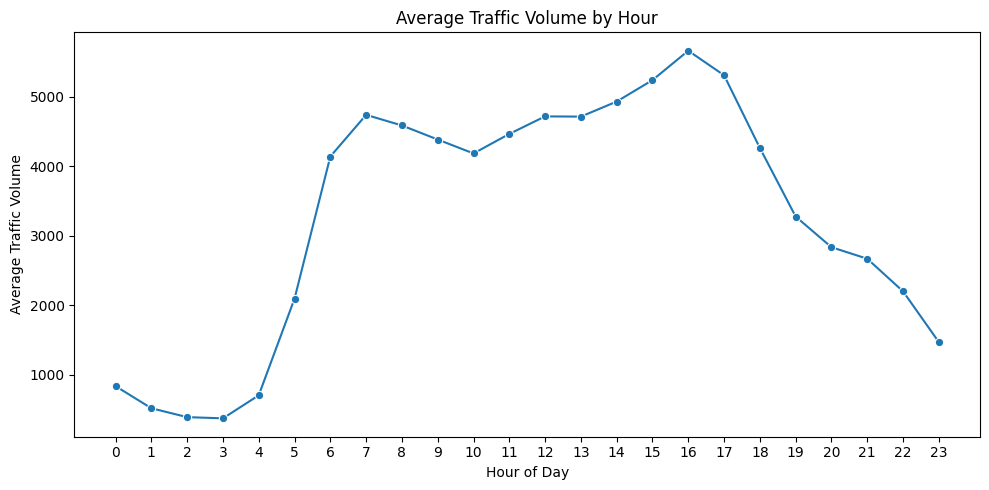

In [13]:
df_hour = df.copy()

df_hour["date_time"] = pd.to_datetime(df_hour["date_time"])
df_hour["hour"] = df_hour["date_time"].dt.hour

hourly_traffic = df_hour.groupby("hour")["traffic_volume"].mean()

plt.figure(figsize=(10, 5))

sns.lineplot(x=hourly_traffic.index, y=hourly_traffic.values, marker="o")

plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

### Observation

Traffic volume varies considerably throughout the day. It is lowest during the early morning hours and increases sharply from around 5 AM, reaching high levels during the morning and evening periods. Highest around 4 PM and then decreases steadily during the night. This indicates that the time of day has a strong relationship with traffic volume.

### Categorical Feature Distributions

The categorical features are examined using frequency plots to understand the distribution of observations across their categories.

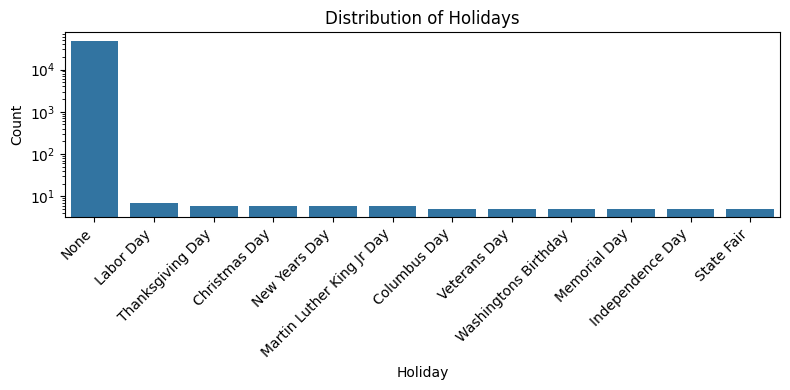

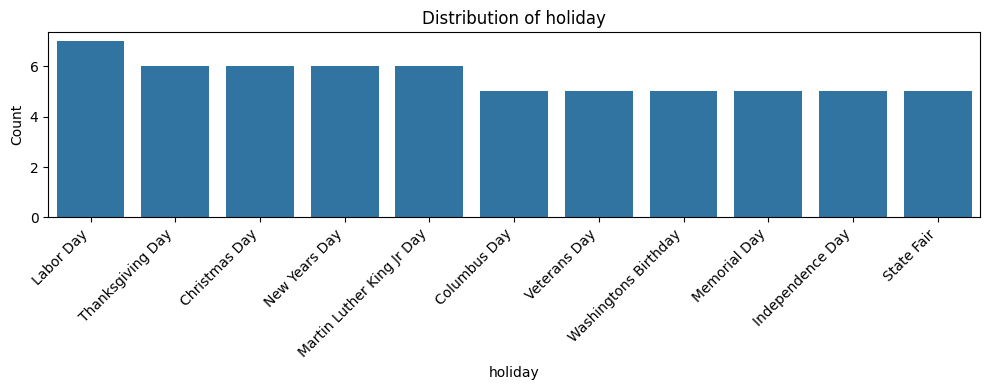

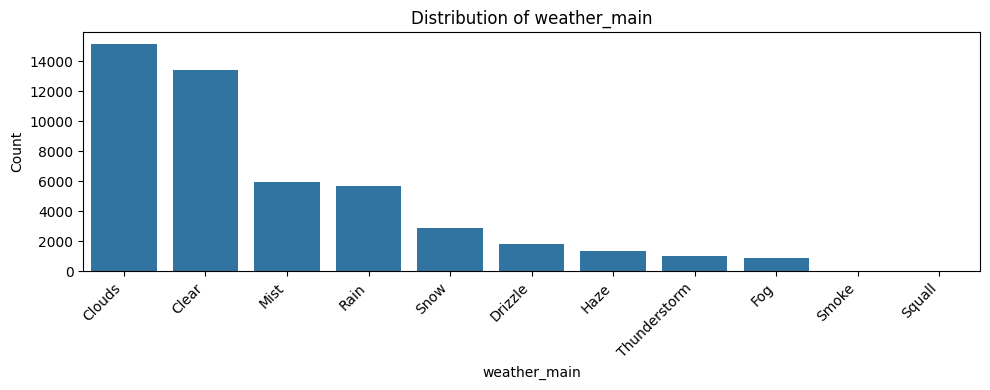

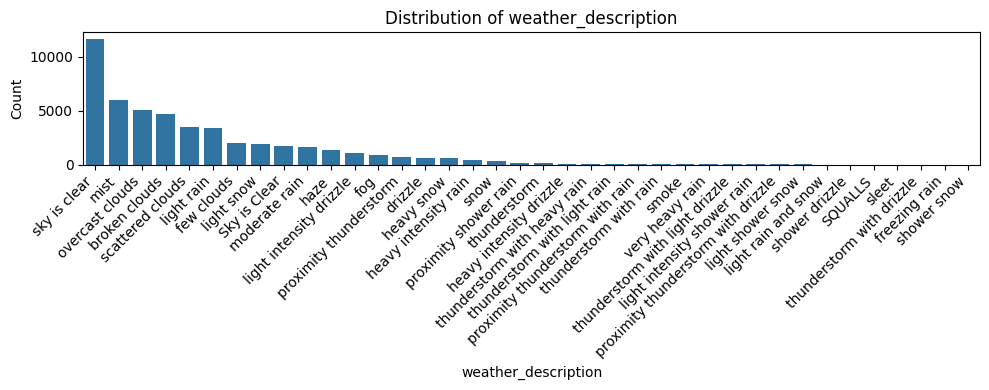

In [14]:
categorical_features = [
    "holiday",
    "weather_main",
    "weather_description"
]

holiday_data = df["holiday"].fillna("None")

plt.figure(figsize=(8, 4))

sns.countplot(x=holiday_data, order=holiday_data.value_counts().index)

plt.title("Distribution of Holidays")
plt.xlabel("Holiday")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.yscale("log")
plt.tight_layout()
plt.show()

for feature in categorical_features:
    plt.figure(figsize=(10, 4))
    
    sns.countplot(data=df, x=feature, order=df[feature].value_counts().index)
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### Observation

- **Holiday:** The `None` category dominates the dataset, while individual holiday categories occur much less frequently and have relatively similar counts.
- **Weather Main:** `Clouds` and `Clear` are the most frequent weather conditions, followed by `Mist` and `Rain`, remaining conditions occur less frequently.
- **Weather Description:** A few descriptions, particularly `sky is clear` and common cloud/mist conditions, account for most observations, while many detailed weather descriptions occur infrequently.
  - **NOTE:** Several weather descriptions are highly frequent, while many others occur less frequently. Some categories also differ only in capitalization, which will be standardized during preprocessing.

### Correlation Heatmap

Used to examine the linear relationships between numerical features and the target variable `traffic_volume`.

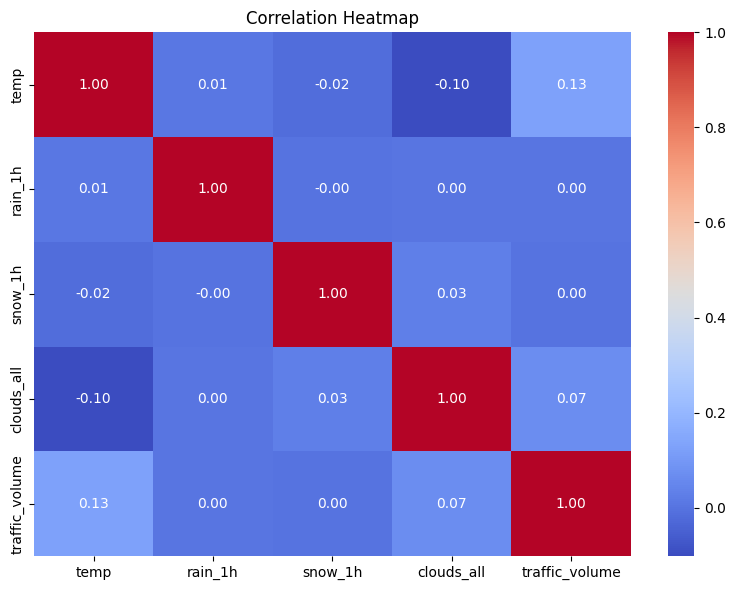

In [15]:
plt.figure(figsize=(8, 6))

correlation_matrix = df[numerical_features + ["traffic_volume"]].corr()

sns.heatmap(correlation_matrix,annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Observation
The correlation matrix shows that the numerical features have relatively weak linear relationships with `traffic_volume`. `temp` had stronget correlation among them, while `rain_1h` and `snow_1h` show almost no linear correlatioon with **Target**. This suggests that traffic volume may depend on multiple factors rather than a single numerical feature.

## Section B - Preprocessing & FeatureEngineering

### Datacleaning

In [16]:
df_clean = df.copy()
print("Missing values before cleaning:\n",df_clean.isnull().sum())
print("Duplicate rows before cleaning:", df_clean.duplicated().sum())
print("Unique weather descriptions before standardization:", df_clean["weather_description"].nunique(), df_clean["weather_description"].unique())
print("Old Shape:", df_clean.shape)

# Cleaning Holiday
df_clean["holiday"] = df_clean["holiday"].fillna("None")

# Drop duplicates
df_clean = df_clean.drop_duplicates()

# Standardize `weather_description` capitalization
df_clean["weather_description"] = (df_clean["weather_description"].str.lower().str.strip())

print("\n Missing values after cleaning:\n",df_clean.isnull().sum())
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())
print("Unique weather descriptions after standardization:", df_clean["weather_description"].nunique())
print("New shape:", df_clean.shape)

Missing values before cleaning:
 holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64
Duplicate rows before cleaning: 17
Unique weather descriptions before standardization: 38 ['scattered clouds' 'broken clouds' 'overcast clouds' 'sky is clear'
 'few clouds' 'light rain' 'light intensity drizzle' 'mist' 'haze' 'fog'
 'proximity shower rain' 'drizzle' 'moderate rain' 'heavy intensity rain'
 'proximity thunderstorm' 'thunderstorm with light rain'
 'proximity thunderstorm with rain' 'heavy snow' 'heavy intensity drizzle'
 'snow' 'thunderstorm with heavy rain' 'freezing rain' 'shower snow'
 'light rain and snow' 'light intensity shower rain' 'SQUALLS'
 'thunderstorm with rain' 'proximity thunderstorm with drizzle'
 'thunderstorm' 'Sky is Clear' 'very heavy rain'
 'thunders

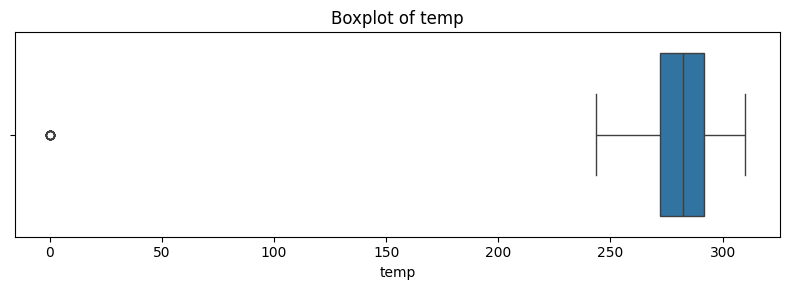

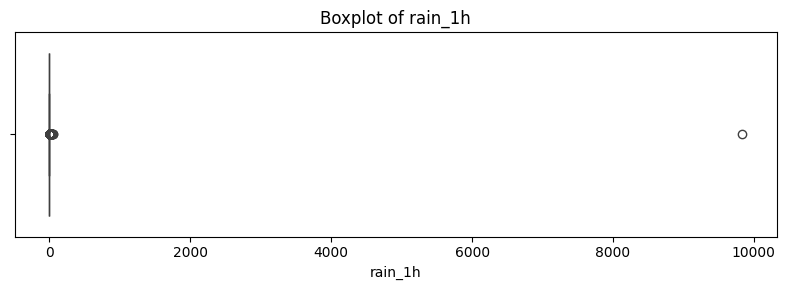

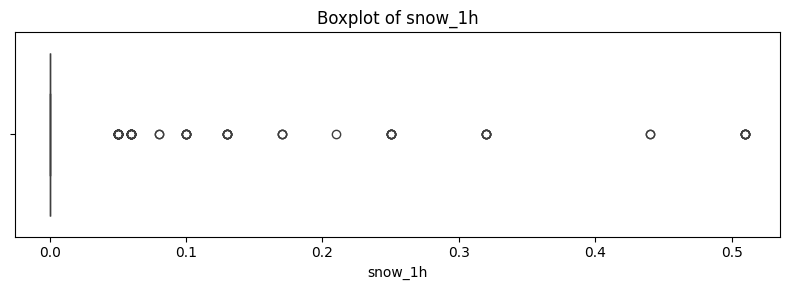

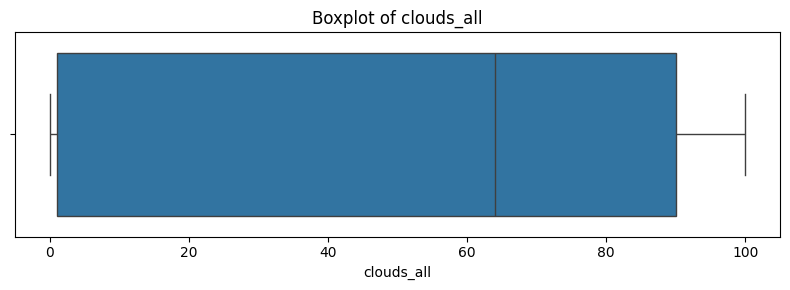

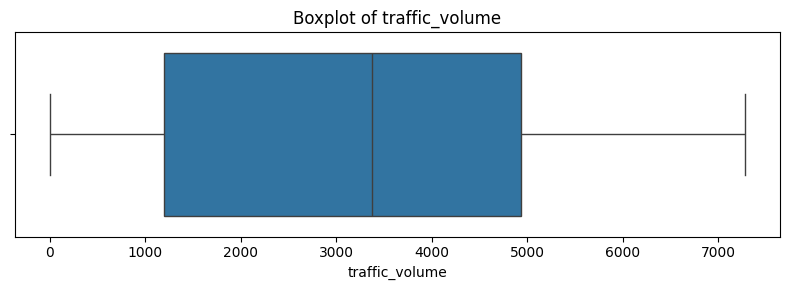

In [17]:
# Outliers
numerical_features = ["temp", "rain_1h", "snow_1h", "clouds_all", "traffic_volume"]

for feature in numerical_features:
    plt.figure(figsize=(8, 3))
    
    sns.boxplot(x=df_clean[feature])
    
    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()

In [18]:
print("Temperature near zero:")
print(df_clean[df_clean["temp"] < 50]["temp"].value_counts())

print("\nHighest rainfall values:")
print(df_clean["rain_1h"].nlargest(10))

print("\nNon-zero snowfall values:")
print(df_clean[df_clean["snow_1h"] > 0]["snow_1h"].value_counts().sort_index())

Temperature near zero:
temp
0.0    10
Name: count, dtype: int64

Highest rainfall values:
24872    9831.30
8247       55.63
7179       44.45
25779      31.75
10806      28.70
10807      28.70
16504      27.57
16505      27.57
16506      27.57
17437      25.46
Name: rain_1h, dtype: float64

Non-zero snowfall values:
snow_1h
0.05    14
0.06    12
0.08     2
0.10     6
0.13     6
0.17     3
0.21     1
0.25     6
0.32     5
0.44     2
0.51     6
Name: count, dtype: int64


In [19]:
print("Rows with temp = 0:")
display(df_clean[df_clean["temp"] == 0])

print("\nRow with extreme rainfall:")
display(df_clean[df_clean["rain_1h"] == df_clean["rain_1h"].max()])

Rows with temp = 0:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
11898,None,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 03:00:00,361
11899,None,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 04:00:00,734
11900,None,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 05:00:00,2557
11901,None,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 06:00:00,5150
11946,None,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 03:00:00,291
11947,None,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 04:00:00,284
11948,None,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 05:00:00,434
11949,None,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 06:00:00,739
11950,None,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 07:00:00,962
11951,None,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 08:00:00,1670



Row with extreme rainfall:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
24872,None,302.11,9831.3,0.0,75,Rain,very heavy rain,2016-07-11 17:00:00,5535


In [20]:
# Remove invalid temperature and rainfall values
df_clean = df_clean[
    (df_clean["temp"] != 0) &
    (df_clean["rain_1h"] < 1000)
].reset_index(drop=True)

print("Shape after removing invalid values:", df_clean.shape)
print("Temperature = 0:", (df_clean["temp"] == 0).sum())
print("Extreme rainfall:", (df_clean["rain_1h"] >= 1000).sum())

Shape after removing invalid values: (48176, 9)
Temperature = 0: 0
Extreme rainfall: 0


### Observation

The boxplots identified unusual values in `temp` and `rain_1h`. Investigation showed that 10 records had `temp = 0 K (-273 C)`, which is an invalid temperature value, and one record had `rain_1h = 9831.3 mm (~9.83 L)`, an unrealistic one-hour rainfall value. These 11 invalid records were removed from the dataset. The non-zero `snow_1h` values were retained because they are within a plausible measurement range.

## Feature Engineering

In [21]:
# Convert date_time to datetime format
df_clean["date_time"] = pd.to_datetime(df_clean["date_time"])

# Extract time-based features
df_clean["hour"] = df_clean["date_time"].dt.hour
df_clean["day_of_week"] = df_clean["date_time"].dt.dayofweek
df_clean["month"] = df_clean["date_time"].dt.month

# A couple of simple flags
df_clean["is_weekend"] = (df_clean["day_of_week"] >= 5).astype(int)
df_clean["is_holiday"] = (df_clean["holiday"] != "None").astype(int)

# Temperature is in Kelvin, convert to Celsius (easier to read, same info)
df_clean["temp_celsius"] = df_clean["temp"] - 273.15

df_clean.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,month,is_weekend,is_holiday,temp_celsius
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1,10,0,0,15.13
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1,10,0,0,16.21
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1,10,0,0,16.43
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1,10,0,0,16.98
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1,10,0,0,17.99


In [22]:
print("\nUpdated shape:", df_clean.shape)


Updated shape: (48176, 15)


### Observation
Time-based features were extracted from `date_time` because traffic patterns can vary by hour, day of the week, and month.`is_weekend` feature was also created to distinguish weekends from weekdays, as traffic behaviour may differ in weekends.

## Feature and Target Split

In [23]:
# Define features and target
# Dropping: date_time (already extracted), temp (kept celsius version),
# holiday (kept is_holiday flag), weather_description (just a more detailed
# copy of weather_main, so it only adds noise / extra one-hot columns).
X = df_clean.drop(columns=["traffic_volume", "date_time", "temp", "holiday", "weather_description"])
y = df_clean["traffic_volume"]

print("Features:")
print(X.columns.tolist())

print("\nx shape:", X.shape)
print("y shape:", y.shape)

Features:
['rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'temp_celsius']

x shape: (48176, 10)
y shape: (48176,)


In [24]:
# Traffic volume is bimodal, so I bin it into deciles and stratify on that
# to keep the train/test distributions similar.
y_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_bins
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (38540, 10)
Testing set: (9636, 10)


## Encoding + Scaling

In [25]:
# The time fields (hour, day_of_week, month) look like numbers but they are
# really categories - traffic at hour 8 vs hour 23 is not a "bigger" number,
# it just behaves differently. So I one-hot encode them instead of scaling.
numerical_features = ["temp_celsius", "rain_1h", "snow_1h", "clouds_all", "is_weekend", "is_holiday"]
time_features = ["hour", "day_of_week", "month"]
categorical_features = ["weather_main"]

In [26]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("time", OneHotEncoder(handle_unknown="ignore"), time_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# feature names for the importance plot later
proc_feature_names = preprocessor.get_feature_names_out()

print("Training data shape after preprocessing:", X_train_proc.shape)
print("Testing data shape after preprocessing:", X_test_proc.shape)

Training data shape after preprocessing: (38540, 59)
Testing data shape after preprocessing: (9636, 59)
